<a href="https://colab.research.google.com/github/Apoorvmittal11/23-CS-072-DL-LAB-EXPERIMENT/blob/main/DL%20EXPERIMENT%206/LSTM_for_stock_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

#**Data Loading and Setup**

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

print("Downloading Stock Data...")
# We will use Apple (AAPL) as our example, from 2015 to 2023
stock_data = yf.download('AAPL', start='2015-01-01', end='2023-01-01')

data = stock_data['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences (e.g., use 60 days of historical data to predict day 61)
SEQ_LENGTH = 60

X, y = [], []
for i in range(len(scaled_data) - SEQ_LENGTH):
    X.append(scaled_data[i:i + SEQ_LENGTH])
    y.append(scaled_data[i + SEQ_LENGTH])
X = np.array(X)
y = np.array(y)

# Split into Training (80%) and Testing (20%) sets
train_size = int(len(X) * 0.8)

X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Data loaded successfully. Training on: {device}")

/tmp/ipykernel_2719/3820044004.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download('AAPL', start='2015-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed

Data loaded successfully. Training on: cpu


#**Defining the LSTM Model**

In [ ]:
class StockPredictorLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(StockPredictorLSTM, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # LSTM Layer
        # input_dim = 1 (just the Close price)
        self.lstm = nn.LSTM(input_size=input_dim,
                            hidden_size=hidden_dim,
                            num_layers=num_layers,
                            batch_first=True)

        # Fully Connected Layer to output the predicted price
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x shape: (batch_size, seq_length, input_dim)

        # Initialize hidden and cell states with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))

        # We only want the output from the last time step
        # out[:, -1, :] shape: (batch_size, hidden_dim)
        out = self.fc(out[:, -1, :])

        return out

#**Initialization & Training Loop**

In [ ]:
INPUT_DIM = 1
HIDDEN_DIM = 50
NUM_LAYERS = 2
OUTPUT_DIM = 1
EPOCHS = 50

model = StockPredictorLSTM(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, OUTPUT_DIM).to(device)

# Mean Squared Error is standard for regression tasks (predicting continuous numbers)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\n--- Starting Training ---")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_X)

        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch+1) % 5 == 0:
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss (MSE): {avg_loss:.5f}")


--- Starting Training ---
Epoch 5/50 | Train Loss (MSE): 0.00033
Epoch 10/50 | Train Loss (MSE): 0.00027
Epoch 15/50 | Train Loss (MSE): 0.00024
Epoch 20/50 | Train Loss (MSE): 0.00020
Epoch 25/50 | Train Loss (MSE): 0.00022
Epoch 30/50 | Train Loss (MSE): 0.00018
Epoch 35/50 | Train Loss (MSE): 0.00015
Epoch 40/50 | Train Loss (MSE): 0.00015
Epoch 45/50 | Train Loss (MSE): 0.00015
Epoch 50/50 | Train Loss (MSE): 0.00013


#**Performance Evaluation**


--- Plotting Results ---


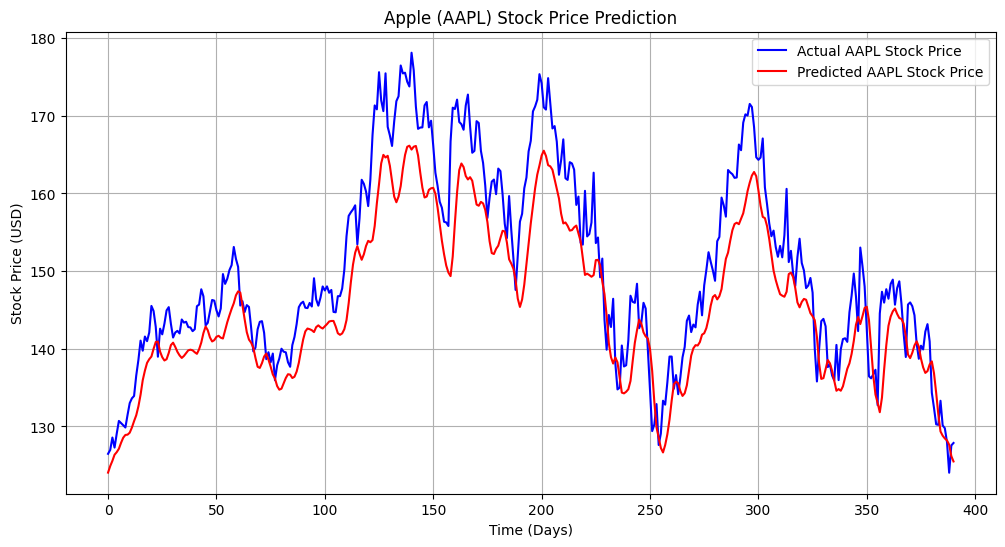

In [ ]:
model.eval()
test_predictions = []

with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        preds = model(batch_X)
        test_predictions.append(preds.cpu().numpy())

# Flatten the predictions array
test_predictions = np.concatenate(test_predictions, axis=0)

# The predictions are still scaled between 0 and 1.
# We must inverse transform them back to real stock prices.
test_predictions_unscaled = scaler.inverse_transform(test_predictions)
y_test_unscaled = scaler.inverse_transform(y_test)

print("\n--- Plotting Results ---")
plt.figure(figsize=(12, 6))
plt.plot(y_test_unscaled, label='Actual AAPL Stock Price', color='blue')
plt.plot(test_predictions_unscaled, label='Predicted AAPL Stock Price', color='red')
plt.title('Apple (AAPL) Stock Price Prediction')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.show()